In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from reprosyn.methods import DS_PRIVBAYES
from utils.tapas.tapas_data_processors import AdultDataProcessor

estimating categorical probs
estimating approx kdes(histogram)
[0.6738168951791242]
Attacking : Raw
Generated datasest of Raw stored at :data/generated_datasets/Raw.pkl
COMPLEXITY:  2
COMPLEXITY:  50
COMPLEXITY:  100
COMPLEXITY:  200
COMPLEXITY:  500
COMPLEXITY:  750
COMPLEXITY:  1000


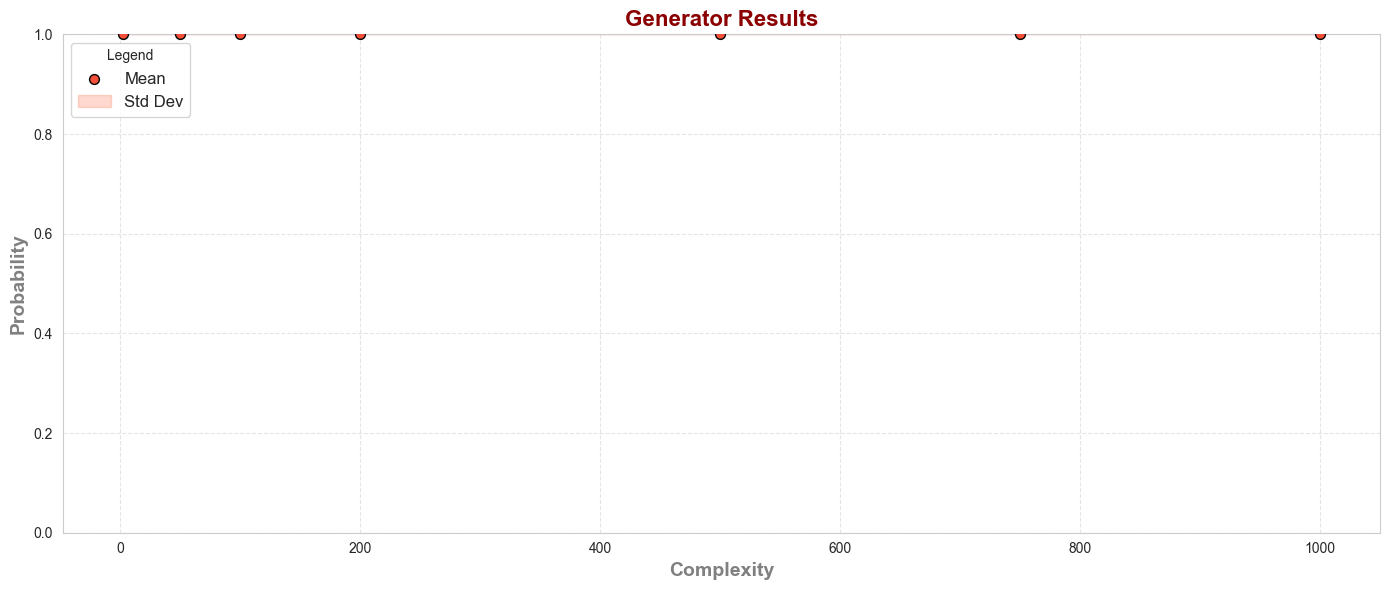

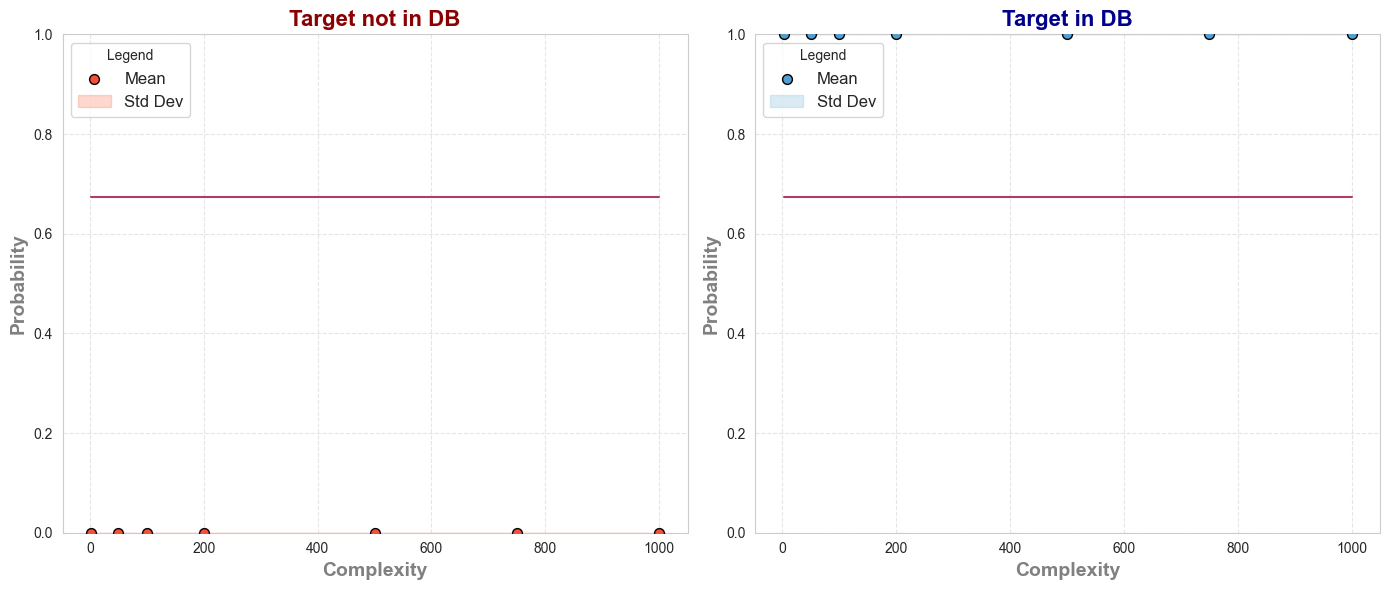

Attacking : PrivBayes_epsilon=1.0
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with PrivBayes
Generating 1000 samples with P

KeyboardInterrupt: 

In [2]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,500))

gen1 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)
gen2 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0, histogram_bins = 10, degree = 2)
gen3 = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0, histogram_bins = 18, degree = 3)


pipeline = BenchmarkPipeline(data, attack, [Raw(), gen1, gen2, gen3], target_record=target_record, size_of_datasets=1000)
benchmarking_metric = AUCMetric()

# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2, 50, 100, 200, 500, 750, 1000], 10, 5,  plot_style='all', benchmarking_metric=benchmarking_metric, 
classification_target_col="income", dcr_metric="gower", generate_data=True)
# pipeline.run([2, 20], 10, 5,  plot_style='all', benchmarking_metric=benchmarking_metric, 
# classification_target_col="income", dcr_metric="gower", generate_data=True)